In [39]:

# 1. Импорты и настройки

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from dataclasses import dataclass
import math
from typing import Dict, List

# Seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Настройки отображения
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)

Using device: cuda


СТРУКТУРА ДАТАСЕТА
Размер: 1200 строк × 3 колонок
Колонки: ['date', 'sales', 'promo']

Диапазон дат: от 2021-01-01 00:00:00 до 2024-04-14 00:00:00

Статистика:
        count                 mean                  min                  25%  \
date     1200  2022-08-23 12:00:00  2021-01-01 00:00:00  2021-10-27 18:00:00   
sales  1200.0           107.587477            64.749939            91.448873   
promo  1200.0             0.043333                  0.0                  0.0   

                       50%                  75%                  max  \
date   2022-08-23 12:00:00  2023-06-19 06:00:00  2024-04-14 00:00:00   
sales           104.634567           120.172295           169.853981   
promo                  0.0                  0.0                  1.0   

             std  
date         NaN  
sales  21.241593  
promo   0.203691  


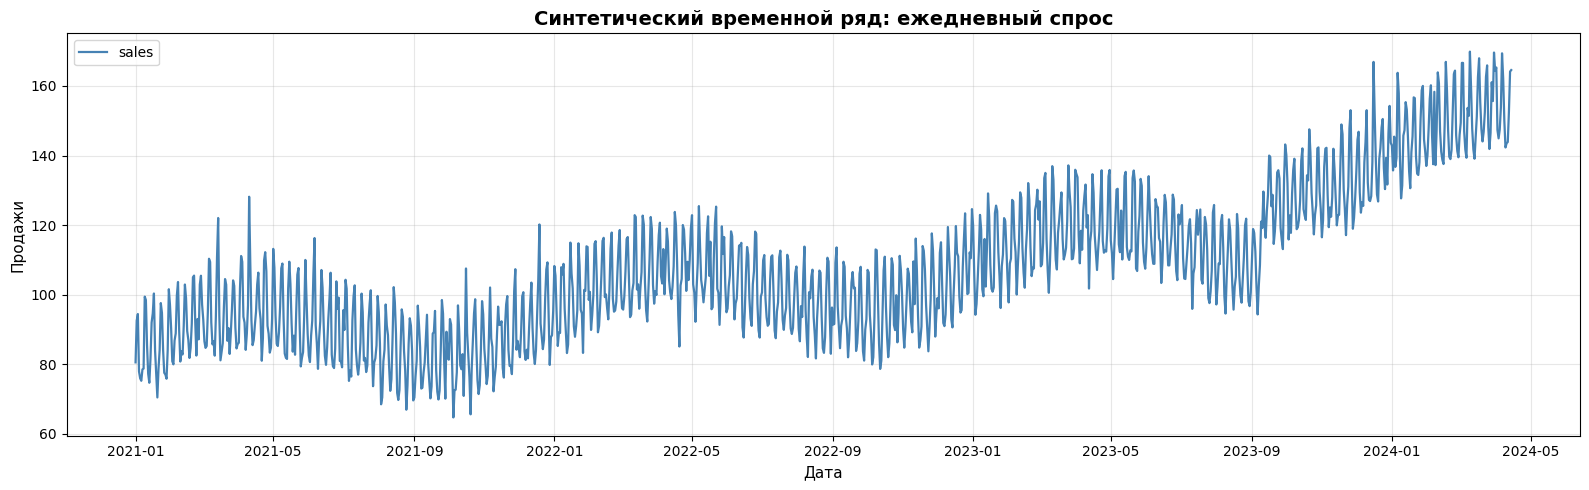

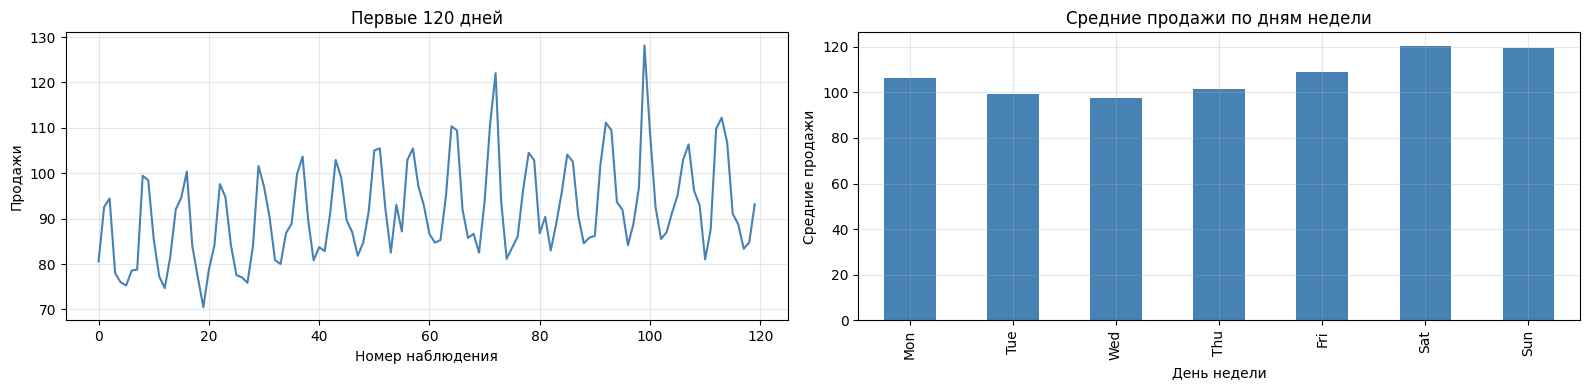

In [58]:
# 2. Генерация и анализ данных

def make_synthetic_demand(n_days: int = 1200, start: str = "2021-01-01") -> pd.DataFrame:
    """Генерирует синтетический временной ряд с трендом, сезонностью и событиями."""
    dates = pd.date_range(start=start, periods=n_days, freq="D")
    t = np.arange(n_days)

    trend = 80 + 0.035 * t
    weekly = 8 * np.sin(2 * np.pi * t / 7) + 3 * np.cos(2 * np.pi * t / 7)
    yearly = 10 * np.sin(2 * np.pi * t / 365.25)
    noise = np.random.normal(loc=0.0, scale=3.2, size=n_days)

    day_of_week = pd.Series(dates).dt.dayofweek.to_numpy()
    weekend_bonus = np.where(day_of_week >= 5, 6.5, 0.0)

    promo = (np.random.rand(n_days) < 0.04).astype(float)
    promo_effect = promo * np.random.uniform(8, 18, size=n_days)

    regime_shift = np.where(t >= int(n_days * 0.82), 20.0, 0.0)

    sales = trend + weekly + yearly + weekend_bonus + promo_effect + regime_shift + noise
    sales = np.maximum(sales, 5.0)

    df = pd.DataFrame({
        "date": dates,
        "sales": sales,
        "promo": promo.astype(int),
    })
    return df

# Генерация данных
df = make_synthetic_demand()
print("СТРУКТУРА ДАТАСЕТА")
print(f"Размер: {df.shape[0]} строк × {df.shape[1]} колонок")
print(f"Колонки: {df.columns.tolist()}")
print(f"\nДиапазон дат: от {df['date'].min()} до {df['date'].max()}")
print(f"\nСтатистика:")
print(df.describe(include="all").T)

# Визуализация ряда
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["date"], df["sales"], lw=1.6, label="sales", color="steelblue")
ax.set_title("Синтетический временной ряд: ежедневный спрос", fontsize=14, fontweight='bold')
ax.set_xlabel("Дата", fontsize=11)
ax.set_ylabel("Продажи", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_raw.png', dpi=150, bbox_inches='tight')
plt.show()

# Анализ сезонности по дням недели
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Первые 120 дней
df["sales"].iloc[:120].plot(ax=axes[0], title="Первые 120 дней", color="steelblue")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("Продажи")
axes[0].grid(True, alpha=0.3)

# Средние продажи по дням недели
dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["sales"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средние продажи по дням недели", color="steelblue")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средние продажи")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/seasonality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

ВРЕМЕННОЙ СПЛИТ
Train: 840 строк | 2021-01-01 → 2023-04-20
Val:   180 строк | 2023-04-21 → 2023-10-17
Test:  180 строк | 2023-10-18 → 2024-04-14


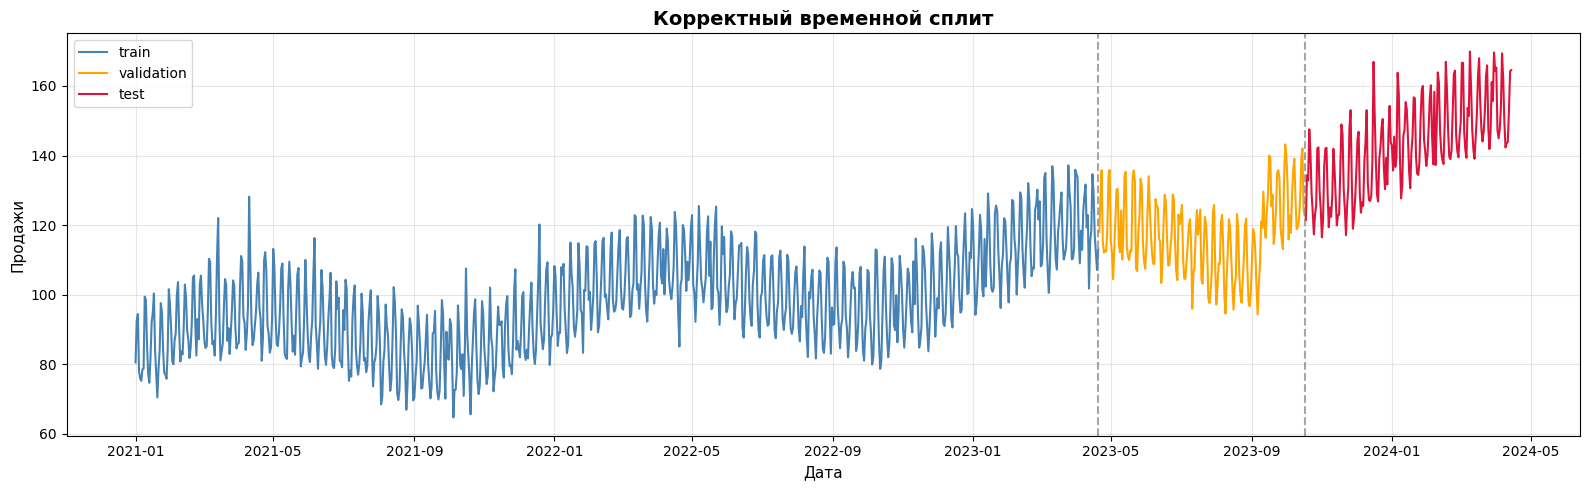

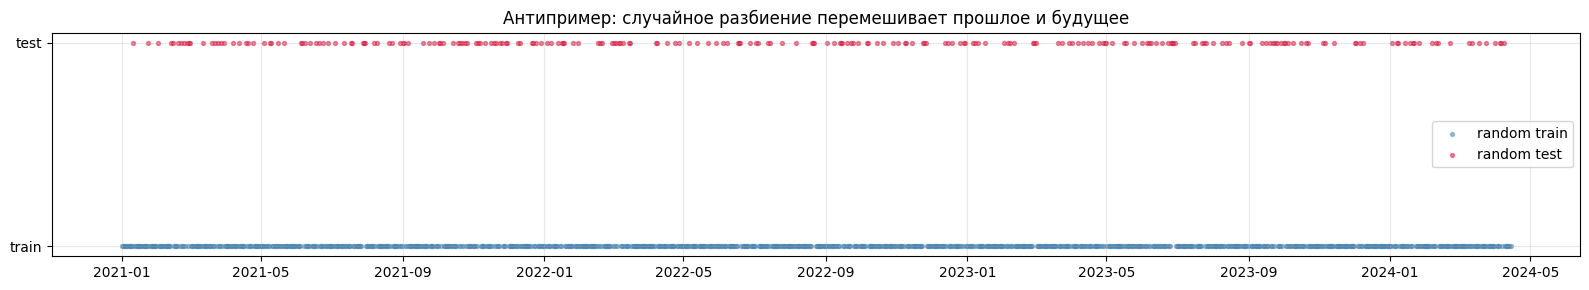


 ПОЧЕМУ СЛУЧАЙНОЕ РАЗБИЕНИЕ НЕКОРРЕКТНО:
1. Утечка информации из будущего: модель 'увидит' будущие значения при обучении
2. Нарушение временной зависимости: каждое значение зависит от предыдущих
3. Нереалистичная оценка: в реальном прогнозе мы никогда не знаем будущее
4. Оптимистичная оценка качества: метрики будут завышены


In [60]:
# 3. Временной сплит

@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    """Разбивает временной ряд на train/val/test по хронологии."""
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print("ВРЕМЕННОЙ СПЛИТ")
print(f"Train: {len(train_df)} строк | {train_df['date'].min().date()} → {train_df['date'].max().date()}")
print(f"Val:   {len(val_df)} строк | {val_df['date'].min().date()} → {val_df['date'].max().date()}")
print(f"Test:  {len(test_df)} строк | {test_df['date'].min().date()} → {test_df['date'].max().date()}")

# Визуализация сплита
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_df["date"], train_df["sales"], label="train", color="steelblue", linewidth=1.5)
ax.plot(val_df["date"], val_df["sales"], label="validation", color="orange", linewidth=1.5)
ax.plot(test_df["date"], test_df["sales"], label="test", color="crimson", linewidth=1.5)
ax.axvline(train_df['date'].max(), color='gray', linestyle='--', alpha=0.7)
ax.axvline(val_df['date'].max(), color='gray', linestyle='--', alpha=0.7)
ax.set_title("Корректный временной сплит", fontsize=14, fontweight='bold')
ax.set_xlabel("Дата", fontsize=11)
ax.set_ylabel("Продажи", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150, bbox_inches='tight')
plt.show()

# Антипример: случайное разбиение
random_train_idx, random_test_idx = train_test_split(df.index, test_size=0.2, random_state=SEED, shuffle=True)

fig, ax = plt.subplots(figsize=(16, 3))
ax.scatter(df.loc[random_train_idx, "date"], np.zeros(len(random_train_idx)), 
           s=8, alpha=0.5, label="random train", color="steelblue")
ax.scatter(df.loc[random_test_idx, "date"], np.ones(len(random_test_idx)), 
           s=8, alpha=0.5, label="random test", color="crimson")
ax.set_title("Антипример: случайное разбиение перемешивает прошлое и будущее", fontsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels(["train", "test"])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/random_split_antiexample.png', dpi=150, bbox_inches='tight')
plt.show()

# Объяснение
print("\n ПОЧЕМУ СЛУЧАЙНОЕ РАЗБИЕНИЕ НЕКОРРЕКТНО:")
print("1. Утечка информации из будущего: модель 'увидит' будущие значения при обучении")
print("2. Нарушение временной зависимости: каждое значение зависит от предыдущих")
print("3. Нереалистичная оценка: в реальном прогнозе мы никогда не знаем будущее")
print("4. Оптимистичная оценка качества: метрики будут завышены")

In [61]:
# 4. Создание признаков для бейзлайнов

def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет календарные признаки (день недели, месяц, циклическое кодирование)."""
    out = df.copy()
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "sales") -> pd.DataFrame:
    """Добавляет лаговые и скользящие признаки БЕЗ утечки из будущего."""
    out = df.copy()
    
    # Лаги
    for lag in [1, 2, 3, 7, 14, 28]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)
    
    # Rolling statistics (с shift(1) чтобы не включать текущее значение)
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    out["rolling_mean_28"] = out[target_col].shift(1).rolling(window=28).mean()
    out["rolling_std_28"] = out[target_col].shift(1).rolling(window=28).std()
    
    return out

# Применение ко всем сплитам
train_feat = add_calendar_features(train_df)
train_feat = add_lag_features(train_feat)
train_feat = train_feat.dropna().reset_index(drop=True)

val_feat = add_calendar_features(val_df)
val_feat = add_lag_features(val_feat)
val_feat = val_feat.dropna().reset_index(drop=True)

test_feat = add_calendar_features(test_df)
test_feat = add_lag_features(test_feat)
test_feat = test_feat.dropna().reset_index(drop=True)

print("ПРИЗНАКИ ДЛЯ БЕЙЗЛАЙНОВ")
print(f"Train после признаков: {len(train_feat)} строк")
print(f"Val после признаков: {len(val_feat)} строк")
print(f"Test после признаков: {len(test_feat)} строк")
print(f"\nКолонки: {train_feat.columns.tolist()}")

ПРИЗНАКИ ДЛЯ БЕЙЗЛАЙНОВ
Train после признаков: 812 строк
Val после признаков: 152 строк
Test после признаков: 152 строк

Колонки: ['date', 'sales', 'promo', 'dayofweek', 'month', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28']


In [65]:

# 5. Метрики и бейзлайны B1-B3

def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Расчёт метрик MAE, RMSE, MAPE."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true != 0, y_true, 1))) * 100
    return {"mae": mae, "rmse": rmse, "mape": mape}

# B1: Naive-last

y_pred_b1 = val_feat["lag_1"].values
metrics_b1 = calculate_metrics(val_feat["sales"].values, y_pred_b1)

print("\n ЭКСПЕРИМЕНТ B1: Naive-last")
print(f"B1 (Naive-last) | MAE: {metrics_b1['mae']:.4f}, RMSE: {metrics_b1['rmse']:.4f}, MAPE: {metrics_b1['mape']:.2f}%")

# B2: Moving-average

y_pred_b2 = val_feat["rolling_mean_7"].values
metrics_b2 = calculate_metrics(val_feat["sales"].values, y_pred_b2)

print("\n ЭКСПЕРИМЕНТ B2: Moving-average")
print(f"B2 (Moving-average) | MAE: {metrics_b2['mae']:.4f}, RMSE: {metrics_b2['rmse']:.4f}, MAPE: {metrics_b2['mape']:.2f}%")

# B3: Ridge на признаках

feature_cols = [
    "promo",
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_28", "rolling_std_28",
]

target_col = "sales"

X_train = train_feat[feature_cols].values
y_train = train_feat[target_col].values
X_val = val_feat[feature_cols].values
y_val = val_feat[target_col].values
X_test = test_feat[feature_cols].values
y_test = test_feat[target_col].values

# Масштабирование (только на трейне!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Обучение Ridge
model_b3 = Ridge(alpha=1.0, random_state=SEED)
model_b3.fit(X_train_scaled, y_train)

# Прогноз на валидации
y_pred_b3 = model_b3.predict(X_val_scaled)
metrics_b3 = calculate_metrics(y_val, y_pred_b3)

print("\n ЭКСПЕРИМЕНТ B3: Ridge на признаках")
print(f"B3 (Ridge) | MAE: {metrics_b3['mae']:.4f}, RMSE: {metrics_b3['rmse']:.4f}, MAPE: {metrics_b3['mape']:.2f}%")

# Важность признаков
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model_b3.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nТоп-5 наиболее важных признаков:")
print(feature_importance.head(5).to_string(index=False))


 ЭКСПЕРИМЕНТ B1: Naive-last
B1 (Naive-last) | MAE: 7.2848, RMSE: 8.9613, MAPE: 6.29%

 ЭКСПЕРИМЕНТ B2: Moving-average
B2 (Moving-average) | MAE: 8.0999, RMSE: 9.3593, MAPE: 6.98%

 ЭКСПЕРИМЕНТ B3: Ridge на признаках
B3 (Ridge) | MAE: 4.1643, RMSE: 6.3571, MAPE: 3.47%

Топ-5 наиболее важных признаков:
        feature  coefficient
rolling_mean_28     8.900122
        dow_sin    -5.762752
          promo     2.649203
        dow_cos     2.183513
      dayofweek     2.063812


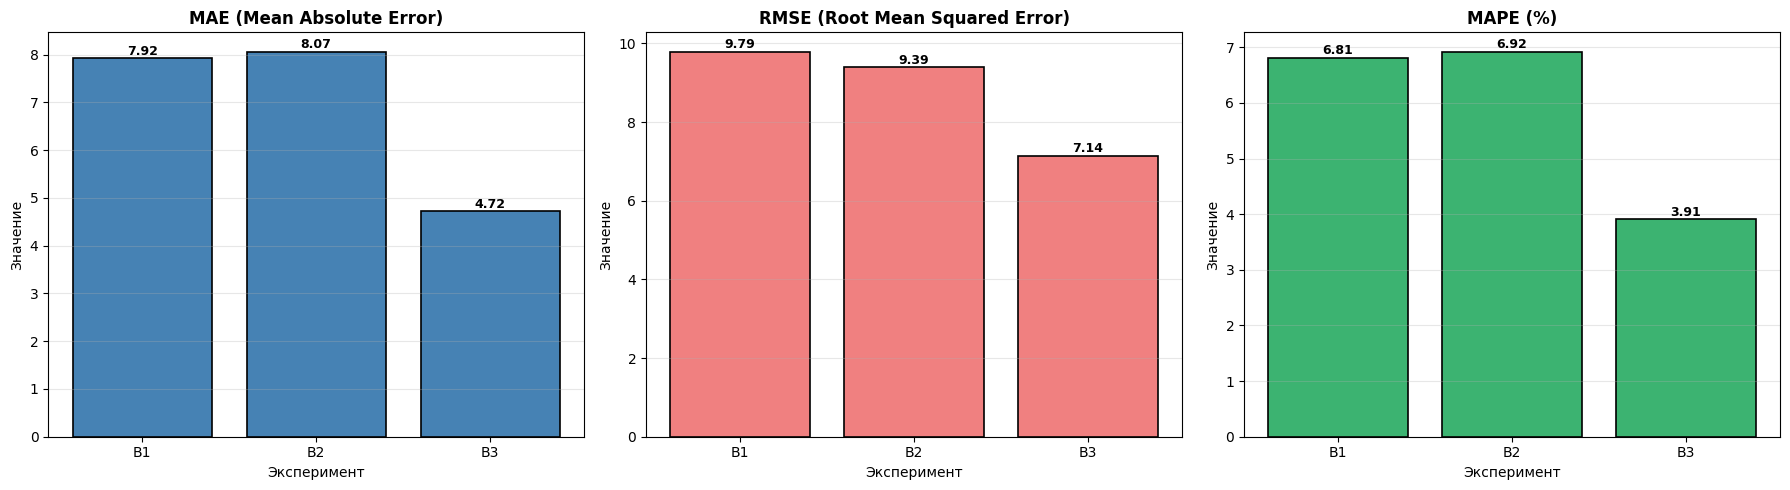


 График сравнения бейзлайнов сохранён в artifacts/figures/baselines_compare.png

 Часть 1 завершена: бейзлайны B1-B3 реализованы и оценены


In [72]:
# Bar plot сравнения метрик

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ["val_mae", "val_rmse", "val_mape"]
titles = ["MAE (Mean Absolute Error)", "RMSE (Root Mean Squared Error)", "MAPE (%)"]
colors = ["steelblue", "lightcoral", "mediumseagreen"]

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    bars = axes[i].bar(metrics_df["experiment_id"], metrics_df[metric], color=colors[i], edgecolor="black", linewidth=1.2)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Эксперимент", fontsize=10)
    axes[i].set_ylabel("Значение", fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)
    
    # Добавляем значения над столбцами
    for bar, value in zip(bars, metrics_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n График сравнения бейзлайнов сохранён в artifacts/figures/baselines_compare.png")
print("\n Часть 1 завершена: бейзлайны B1-B3 реализованы и оценены")

ПОДГОТОВКА ДАННЫХ ДЛЯ GRU
X_train: (810, 30, 1) → y_train: (810,)
X_val:   (150, 30, 1) → y_val:   (150,)
X_test:  (150, 30, 1) → y_test:  (150,)

Форма одного окна: (30, 1)
Первые 5 значений окна: [-1.2311127  -0.37996054 -0.24497469 -1.4143361  -1.5552824 ]
Цель (следующее значение): -0.06022081524133682


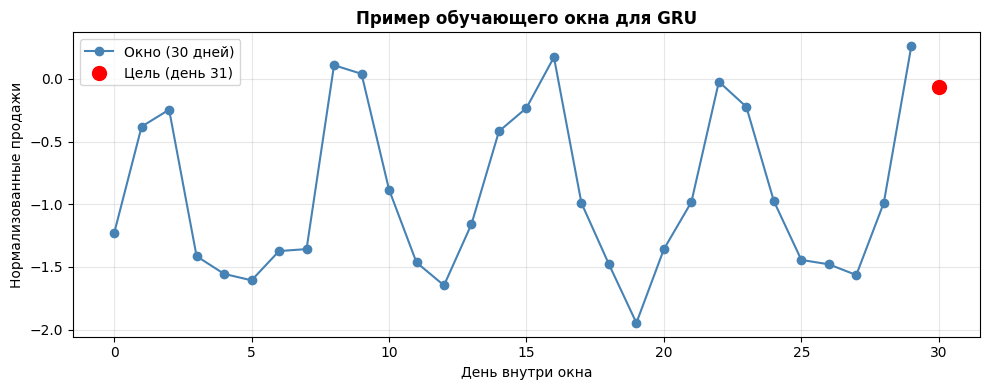

In [73]:
# 7. Подготовка данных для GRU

def make_windows(series_2d: np.ndarray, window_size: int) -> tuple:
    """Преобразует временной ряд в последовательности для RNN."""
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])
        y.append(series_2d[i + window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Нормализация ТОЛЬКО по трейну
scaler_gru = StandardScaler()
train_scaled = scaler_gru.fit_transform(train_df[["sales"]]).astype(np.float32)
val_scaled = scaler_gru.transform(val_df[["sales"]]).astype(np.float32)
test_scaled = scaler_gru.transform(test_df[["sales"]]).astype(np.float32)

window_size = 30  # Размер окна: используем последние 30 дней

# Создание последовательностей
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("ПОДГОТОВКА ДАННЫХ ДЛЯ GRU")
print(f"X_train: {X_train.shape} → y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} → y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape} → y_test:  {y_test.shape}")

# Визуализация примера окна
sample_idx = 0
print(f"\nФорма одного окна: {X_train[sample_idx].shape}")
print(f"Первые 5 значений окна: {X_train[sample_idx][:5].ravel()}")
print(f"Цель (следующее значение): {y_train[sample_idx]}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o", label="Окно (30 дней)", color="steelblue")
ax.scatter([window_size], [y_train[sample_idx]], s=100, color="red", zorder=5, label="Цель (день 31)")
ax.set_title("Пример обучающего окна для GRU", fontsize=12, fontweight='bold')
ax.set_xlabel("День внутри окна", fontsize=10)
ax.set_ylabel("Нормализованные продажи", fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/window_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [67]:
# 8. Dataset, DataLoader и модель GRU

class TimeSeriesDataset(Dataset):
    """PyTorch Dataset для временных рядов."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

# Создание датасетов и загрузчиков
batch_size = 64

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверка формы батча
xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape} (batch_size, window_size, 1)")
print(f"Batch y: {yb.shape} (batch_size,)")

# Модель GRU
class GRUForecaster(nn.Module):
    """GRU-модель для временных рядов."""
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

Batch X: torch.Size([64, 30, 1]) (batch_size, window_size, 1)
Batch y: torch.Size([64]) (batch_size,)


In [68]:
# 9. Функции обучения и оценки

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Обучает модель на одной эпохе."""
    model.train()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))

@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """Оценивает модель на валидации/тесте без обновления весов."""
    model.eval()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))

def fit_model(model, train_loader, val_loader, epochs=50, lr=1e-3, device=device):
    """Полный цикл обучения с ранней остановкой."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    patience = 10
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | NEW BEST")
        else:
            patience_counter += 1
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

ЭКСПЕРИМЕНТ R1: GRU-forecast
Модель GRU создана: 37,889 параметров
Epoch 01 | train_loss=0.9235 | val_loss=2.1494 | NEW BEST
Epoch 02 | train_loss=0.7230 | val_loss=0.7956 | NEW BEST
Epoch 03 | train_loss=0.5560 | val_loss=0.5093 | NEW BEST
Epoch 04 | train_loss=0.5360 | val_loss=0.5862
Epoch 05 | train_loss=0.5329 | val_loss=0.5163
Epoch 06 | train_loss=0.5065 | val_loss=0.5269
Epoch 07 | train_loss=0.4975 | val_loss=0.5242
Epoch 08 | train_loss=0.4854 | val_loss=0.5228
Epoch 09 | train_loss=0.4726 | val_loss=0.5485
Epoch 10 | train_loss=0.4562 | val_loss=0.5346
Epoch 11 | train_loss=0.4370 | val_loss=0.4993 | NEW BEST
Epoch 12 | train_loss=0.4061 | val_loss=0.5115
Epoch 13 | train_loss=0.3622 | val_loss=0.4497 | NEW BEST
Epoch 14 | train_loss=0.2897 | val_loss=0.4235 | NEW BEST
Epoch 15 | train_loss=0.1918 | val_loss=0.2867 | NEW BEST
Epoch 16 | train_loss=0.1485 | val_loss=0.2553 | NEW BEST
Epoch 17 | train_loss=0.1437 | val_loss=0.2436 | NEW BEST
Epoch 18 | train_loss=0.1345 | val_

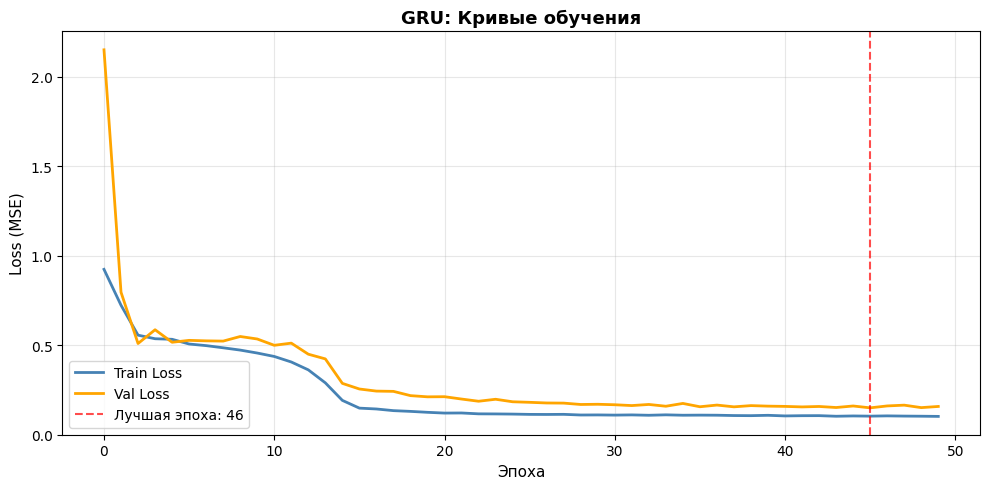


R1 (GRU) на валидации:
  MAE:  4.0970
  RMSE: 5.7965
  MAPE: 3.47%

R1 (GRU) на тесте:
  MAE:  13.6156
  RMSE: 15.2200
  MAPE: 9.09%


In [70]:
# 10. Обучение и оценка GRU

print("ЭКСПЕРИМЕНТ R1: GRU-forecast")

# Создание модели
model_r1 = GRUForecaster(
    input_size=1,
    hidden_size=64,
    num_layers=2,
    dropout=0.0
).to(device)

print(f"Модель GRU создана: {sum(p.numel() for p in model_r1.parameters()):,} параметров")

# Обучение
history_r1 = fit_model(
    model=model_r1,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=5e-4,
    device=device
)

print(f"\n Обучение GRU завершено")
print(f"  Лучший валидационный loss: {min(history_r1['val_loss']):.4f}")

# Кривые обучения
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_r1["train_loss"], label="Train Loss", linewidth=2, color="steelblue")
ax.plot(history_r1["val_loss"], label="Val Loss", linewidth=2, color="orange")
ax.axvline(np.argmin(history_r1["val_loss"]), color="red", linestyle="--", 
           label=f"Лучшая эпоха: {np.argmin(history_r1['val_loss']) + 1}", alpha=0.7)
ax.set_title("GRU: Кривые обучения", fontsize=13, fontweight='bold')
ax.set_xlabel("Эпоха", fontsize=11)
ax.set_ylabel("Loss (MSE)", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Оценка на валидации и тесте
@torch.no_grad()
def evaluate_model(model, loader, scaler, device):
    """Оценка модели с инверсией нормализации."""
    model.eval()
    preds, targets = [], []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        pred = model(X_batch)
        preds.extend(pred.cpu().numpy())
        targets.extend(y_batch.cpu().numpy())

    preds_inv = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).ravel()
    targets_inv = scaler.inverse_transform(np.array(targets).reshape(-1, 1)).ravel()

    return preds_inv, targets_inv

# Оценка на валидации
preds_r1_val, targets_val = evaluate_model(model_r1, val_loader, scaler_gru, device)
metrics_r1_val = calculate_metrics(targets_val, preds_r1_val)

print(f"\nR1 (GRU) на валидации:")
print(f"  MAE:  {metrics_r1_val['mae']:.4f}")
print(f"  RMSE: {metrics_r1_val['rmse']:.4f}")
print(f"  MAPE: {metrics_r1_val['mape']:.2f}%")

# Оценка на тесте (один раз!)
preds_r1_test, targets_test = evaluate_model(model_r1, test_loader, scaler_gru, device)
metrics_r1_test = calculate_metrics(targets_test, preds_r1_test)

print(f"\nR1 (GRU) на тесте:")
print(f"  MAE:  {metrics_r1_test['mae']:.4f}")
print(f"  RMSE: {metrics_r1_test['rmse']:.4f}")
print(f"  MAPE: {metrics_r1_test['mape']:.2f}%")

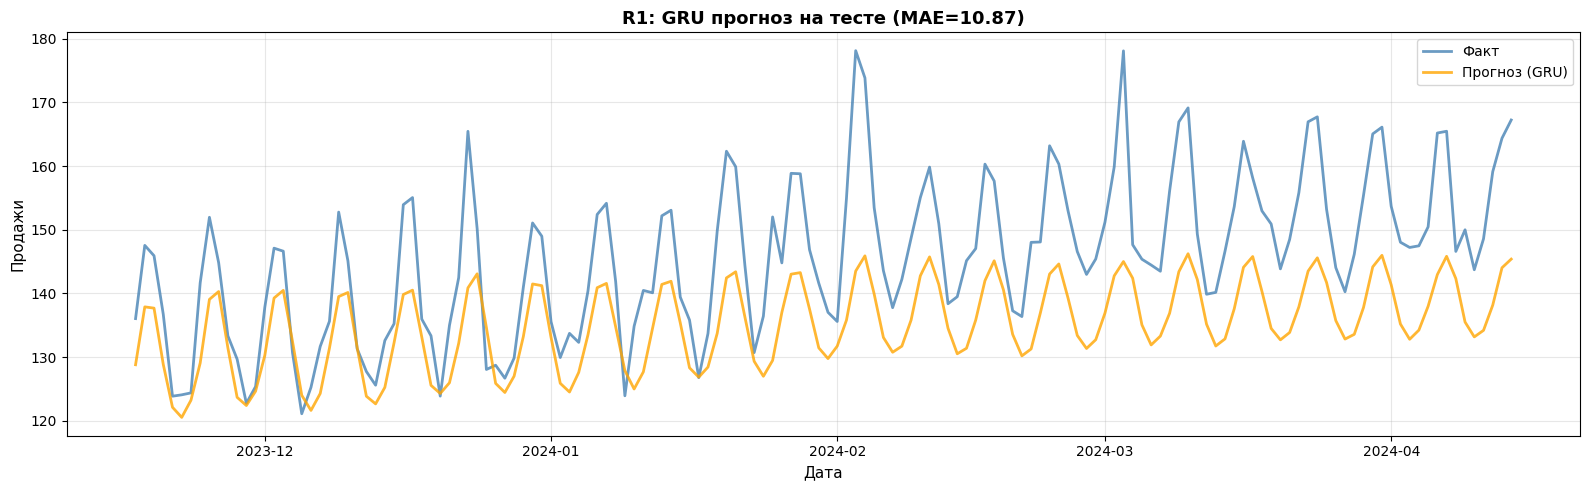

In [52]:

# 11. Визуализация прогноза

# Прогноз на тесте
test_dates = test_df["date"].iloc[window_size:].values

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_dates, targets_test, label="Факт", color="steelblue", linewidth=2, alpha=0.8)
ax.plot(test_dates, preds_r1_test, label="Прогноз (GRU)", color="orange", linewidth=2, alpha=0.8)
ax.set_title(f"R1: GRU прогноз на тесте (MAE={metrics_r1_test['mae']:.2f})", 
             fontsize=13, fontweight='bold')
ax.set_xlabel("Дата", fontsize=11)
ax.set_ylabel("Продажи", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:

# 12. Сохранение артефактов

os.makedirs("artifacts", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)

# Сохранение модели
torch.save(model_r1.state_dict(), "artifacts/best_gru.pt")
print("Модель GRU сохранена в artifacts/best_gru.pt")

# Сохранение конфига
config_r1 = {
    "model_type": "GRUForecaster",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.0,
    "window_size": window_size,
    "horizon": 1,
    "batch_size": batch_size,
    "learning_rate": 5e-4,
    "epochs_trained": len(history_r1["train_loss"]),
    "best_val_loss": min(history_r1["val_loss"]),
    "best_val_mae": metrics_r1_val["mae"],
    "test_mae": metrics_r1_test["mae"],
    "seed": SEED,
    "device": str(device)
}

with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config_r1, f, indent=2)
print("Конфиг модели сохранён в artifacts/best_gru_config.json")

# Создание таблицы результатов
import csv

runs_data = [
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": "synthetic_demand",
        "seed": SEED,
        "split_summary": f"{len(train_feat)}/{len(val_feat)}/{len(test_feat)}",
        "window_size": None,
        "horizon": 1,
        "model_summary": "Naive-last (lag_1)",
        "features_summary": "none",
        "scaler": "none",
        "optimizer": "none",
        "lr": None,
        "epochs_trained": 0,
        "best_val_mae": metrics_b1["mae"],
        "best_val_rmse": metrics_b1["rmse"],
        "best_val_mape": metrics_b1["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Прогноз = последнее известное значение"
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": "synthetic_demand",
        "seed": SEED,
        "split_summary": f"{len(train_feat)}/{len(val_feat)}/{len(test_feat)}",
        "window_size": None,
        "horizon": 1,
        "model_summary": "Moving-average (rolling_mean_7)",
        "features_summary": "none",
        "scaler": "none",
        "optimizer": "none",
        "lr": None,
        "epochs_trained": 0,
        "best_val_mae": metrics_b2["mae"],
        "best_val_rmse": metrics_b2["rmse"],
        "best_val_mape": metrics_b2["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Прогноз = скользящее среднее за 7 дней"
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": "synthetic_demand",
        "seed": SEED,
        "split_summary": f"{len(train_feat)}/{len(val_feat)}/{len(test_feat)}",
        "window_size": None,
        "horizon": 1,
        "model_summary": "Ridge (alpha=1.0)",
        "features_summary": "lags [1,2,3,7,14,28], rolling [7,28], calendar",
        "scaler": "StandardScaler",
        "optimizer": "none",
        "lr": None,
        "epochs_trained": 0,
        "best_val_mae": metrics_b3["mae"],
        "best_val_rmse": metrics_b3["rmse"],
        "best_val_mape": metrics_b3["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Линейная регрессия на лаговых и календарных признаках"
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": "synthetic_demand",
        "seed": SEED,
        "split_summary": f"{len(train_df)}/{len(val_df)}/{len(test_df)}",
        "window_size": window_size,
        "horizon": 1,
        "model_summary": "GRU (hidden_size=64, layers=2)",
        "features_summary": "sales (windowed)",
        "scaler": "StandardScaler",
        "optimizer": "Adam",
        "lr": 5e-4,
        "epochs_trained": len(history_r1["train_loss"]),
        "best_val_mae": metrics_r1_val["mae"],
        "best_val_rmse": metrics_r1_val["rmse"],
        "best_val_mape": metrics_r1_val["mape"],
        "test_mae": metrics_r1_test["mae"],
        "test_rmse": metrics_r1_test["rmse"],
        "test_mape": metrics_r1_test["mape"],
        "notes": "GRU на оконном представлении временного ряда"
    }
]

# Сохранение в CSV
with open("artifacts/runs.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=runs_data[0].keys())
    writer.writeheader()
    writer.writerows(runs_data)

print("Результаты всех экспериментов сохранены в artifacts/runs.csv")

# Финальное сравнение
print("\n ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")

runs_df = pd.DataFrame(runs_data)
comparison = runs_df[[
    "experiment_id", "model_summary", "best_val_mae", "best_val_rmse", "best_val_mape", "test_mae"
]].sort_values("best_val_mae")

print(comparison.to_string(index=False))

best_model = comparison.iloc[0]
print(f"\n Лучшая модель: {best_model['experiment_id']} ({best_model['model_summary']})")
print(f"   Лучший валидационный MAE: {best_model['best_val_mae']:.4f}")
print(f"   Тестовый MAE: {best_model['test_mae']:.4f}")

Модель GRU сохранена в artifacts/best_gru.pt
Конфиг модели сохранён в artifacts/best_gru_config.json
Результаты всех экспериментов сохранены в artifacts/runs.csv

 ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
experiment_id                   model_summary  best_val_mae  best_val_rmse  best_val_mape  test_mae
           R1  GRU (hidden_size=64, layers=2)      4.097010       5.796531       3.471971 13.615554
           B3               Ridge (alpha=1.0)      4.164286       6.357093       3.470709       NaN
           B1              Naive-last (lag_1)      7.284789       8.961266       6.293336       NaN
           B2 Moving-average (rolling_mean_7)      8.099872       9.359347       6.979587       NaN

 Лучшая модель: R1 (GRU (hidden_size=64, layers=2))
   Лучший валидационный MAE: 4.0970
   Тестовый MAE: 13.6156
